# Week 3 · Notebook 1 — Financial Data & Feature Engineering
### Multi-Agent Forecasting Project

**Name:**  
**Date:**  

---
From this week the project becomes **real**: we forecast the daily moves of the **S&P 500** (via the `SPY` ETF) using live market data.

This is the first of six notebooks. Each one builds a single piece of the final multi-agent system. By the end of all six, the notebooks *together* are the project. This notebook builds the **data + feature layer** that every later agent will consume.

**Topics covered:**
1. From prices to **log returns** — and why we never forecast raw prices
2. Volatility and the **VIX** fear index
3. The **RSI** momentum indicator (coded from scratch)
4. The **MACD** trend indicator
5. **Bollinger Band width** as a volatility feature
6. Assembling a clean **feature matrix** — with zero future leakage

> **The golden rule of this project:** every feature you build to predict day *t* may only use information available *before* day *t*. One stray un-shifted column and your backtest becomes a fantasy. We will check for this explicitly.

In [1]:
# Run this cell first — installs and imports everything you need.
# In Google Colab, yfinance is usually pre-installed; if not, this installs it.
!pip -q install yfinance

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

START = '2010-01-01'
END   = '2024-12-31'
print('Setup complete.')

Setup complete.


---
## Section 1 — From Prices to Log Returns

Stock **prices** are non-stationary: their mean and variance drift over time (SPY was ~$100 in 2010 and ~$580 in 2024). Models trained on one price range generalise terribly to another.

**Returns** fix this. The *log return* on day *t* is:

$$ r_t = \\log\\left( \\frac{P_t}{P_{t-1}} \\right) = \\log P_t - \\log P_{t-1} $$

Log returns are (approximately) stationary, they are additive over time, and they are symmetric around zero. **This `log_return` is the target our whole project predicts.**

**Read:** [Why log returns?](https://quantivity.wordpress.com/2011/02/21/why-log-returns/)

In [2]:
# --- EXAMPLE: download SPY and compute log returns ---
spy = yf.download('SPY', start=START, end=END, auto_adjust=True, progress=False)
spy = spy[['Close']].copy()
spy.columns = ['Close']
spy['log_return'] = np.log(spy['Close'] / spy['Close'].shift(1))
spy.dropna(inplace=True)

print('SPY rows:', len(spy))
print(spy.head())

SPY rows: 3772
                Close  log_return
Date                             
2010-01-05  84.802361    0.002643
2010-01-06  84.862114    0.000704
2010-01-07  85.220276    0.004212
2010-01-08  85.503868    0.003322
2010-01-11  85.623291    0.001396


### Exercise 1.1 — Visualise Price vs Returns

Make a figure with **two stacked subplots** sharing the x-axis:
1. Top: the SPY `Close` price
2. Bottom: the `log_return`

Then, in the cell below, describe the visual difference: which series looks *stationary* (constant mean / variance) and which does not?

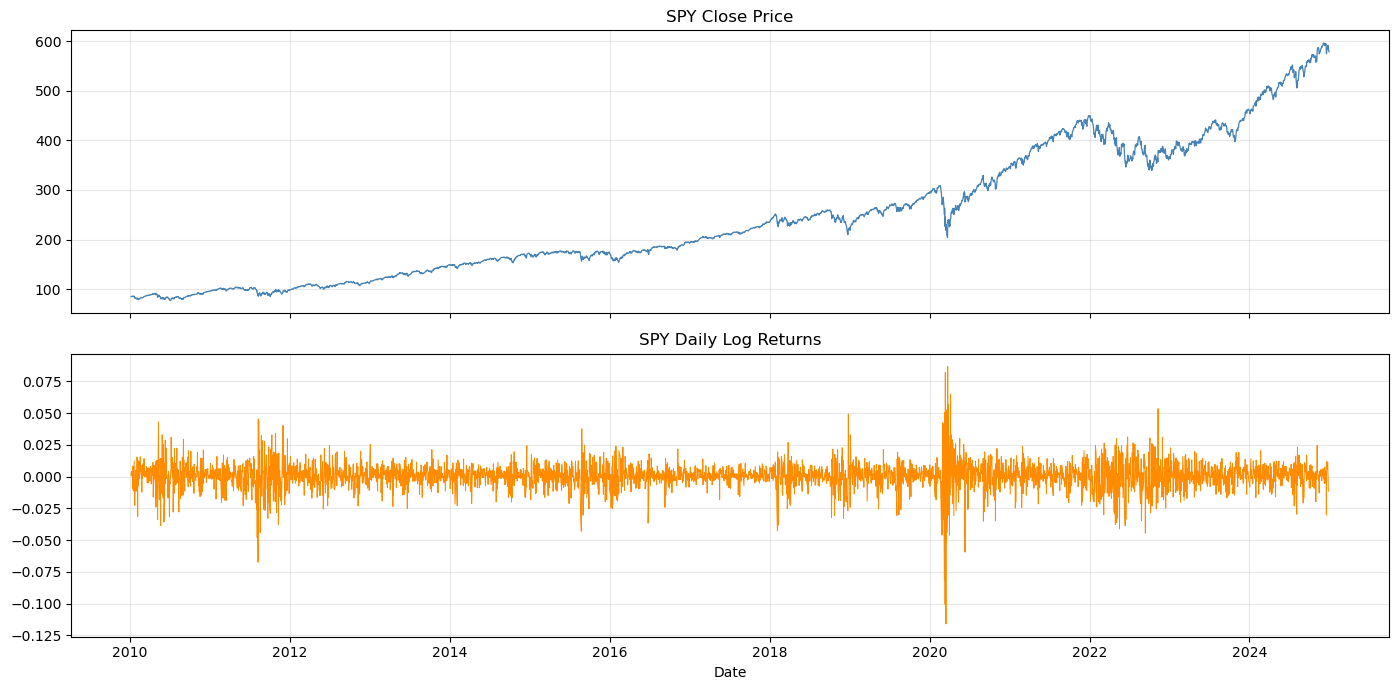

In [3]:
# YOUR CODE HERE
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(14, 7))

# Top: price
ax1.plot(spy.index, spy['Close'], color='steelblue', linewidth=0.9)

# Bottom: log returns
ax2.plot(spy.index, spy['log_return'], color='darkorange', linewidth=0.7)

ax1.set_title('SPY Close Price')
ax2.set_title('SPY Daily Log Returns')
ax2.set_xlabel('Date')
plt.tight_layout()
plt.show()

**Which series is stationary and which is not? What does the bottom plot tell you about *when* volatility clusters (e.g. 2020)?**



### Exercise 1.2 — Short Answer

1. Give two concrete reasons we forecast **log returns** instead of raw prices.
2. The log return uses `.shift(1)` in the denominator. In one sentence, why is that `.shift(1)` essential for avoiding *lookahead bias*?

**Your answers:**

1. 1. Two reasons we forecast log returns instead of raw prices:

Stationarity — Raw prices drift up over time, so a model trained on 2010–2015 prices has no idea what to do with 2024 prices. Log returns fluctuate around zero with (roughly) constant variance, making patterns actually transferable across time.
Additivity — Log returns add up across time. The 5-day return is simply the sum of five daily log returns. This makes them mathematically convenient for compounding and aggregation.

2. Without .shift(1), you'd be dividing today's price by itself (or using today's price in the denominator), which means you'd be using today's information to predict today's return — that's lookahead bias, and your model would be cheating.


---
## Section 2 — Volatility and the VIX

The **VIX** is the market's expected 30-day volatility, implied by S&P 500 option prices — often called the *fear index*. When markets panic, the VIX spikes. It is one of the most useful external signals for predicting *how big* tomorrow's move will be.

We download it from Yahoo Finance under the ticker `^VIX`, and engineer one extra feature: its **5-day percentage change**, which captures whether fear is rising or falling.

In [4]:
# --- EXAMPLE: download the VIX ---
vix = yf.download('^VIX', start=START, end=END, auto_adjust=True, progress=False)
vix = vix[['Close']].copy()
vix.columns = ['vix_close']
vix['vix_change_5d'] = vix['vix_close'].pct_change(5)
vix.dropna(inplace=True)
print(vix.head())

            vix_close  vix_change_5d
Date                                
2010-01-11  17.549999      -0.124252
2010-01-12  18.250000      -0.056848
2010-01-13  17.850000      -0.068372
2010-01-14  17.629999      -0.075026
2010-01-15  17.910000      -0.012135


### Exercise 2.1 — Merge SPY and VIX into One Dataset

1. Join `spy` and `vix` on their shared dates with an **inner** join (so every row has both SPY and VIX data). Call the result `df`.
2. Drop any rows with `NaN`.
3. Print the final shape and confirm `df` has the columns: `Close`, `log_return`, `vix_close`, `vix_change_5d`.
4. Plot the VIX over time and visually confirm the big spike around the **2020 COVID crash**.

Merged shape: (3768, 4)
Columns: ['Close', 'log_return', 'vix_close', 'vix_change_5d']


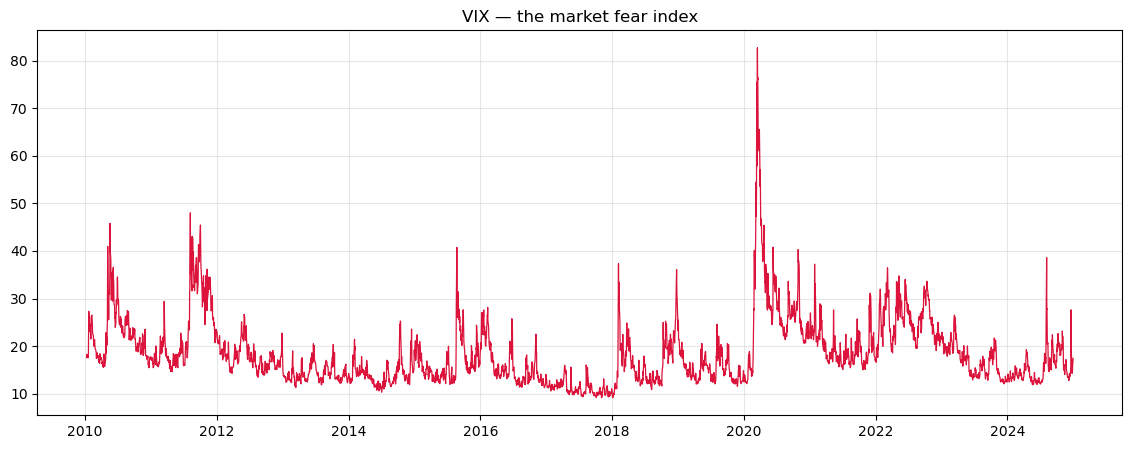

In [5]:
# YOUR CODE HERE
# 1. Inner join
df = spy.join(vix, how='inner')

# 2. Drop NaNs
df =  df.dropna()

# 3. Inspect
print('Merged shape:', df.shape)
print('Columns:', list(df.columns))

# 4. Plot the VIX
fig, ax = plt.subplots()
ax.plot(df.index, df['vix_close'], color='crimson', linewidth=0.9)
ax.set_title('VIX — the market fear index')
plt.show()

---
## Section 3 — RSI: The Relative Strength Index

**RSI** is a classic momentum oscillator bounded between 0 and 100. It compares the average size of recent *up* moves to recent *down* moves:

$$ RSI = 100 - \\frac{100}{1 + RS}, \\qquad RS = \\frac{\\text{avg gain}}{\\text{avg loss}} $$

Readings above 70 suggest an asset is "overbought", below 30 "oversold". Our `MomentumAgent` will use it later. We compute the averages with an **exponentially weighted mean** (`.ewm`), the standard Wilder smoothing.

**Read:** [RSI explained](https://www.investopedia.com/terms/r/rsi.asp)

### Exercise 3.1 — Implement `compute_rsi`

Fill in the function. Steps:
1. `delta` = the day-to-day difference of the price series (`.diff()`)
2. `gain` = the positive part of `delta` (use `.clip(lower=0)`); `loss` = the negative part made positive (`-delta.clip(upper=0)`)
3. `avg_gain` / `avg_loss` = exponentially weighted means with `com=period-1`, `min_periods=period`
4. `rs = avg_gain / avg_loss` (replace 0 losses with `np.nan` to avoid divide-by-zero)
5. Return `100 - 100 / (1 + rs)`

RSI range: 16.8 to 87.2


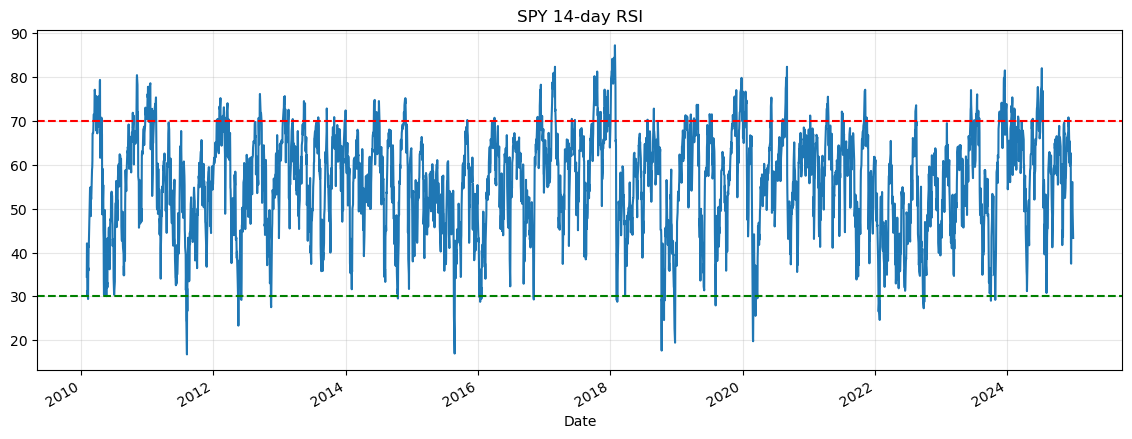

In [6]:
# YOUR CODE HERE
def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """Relative Strength Index, computed with Wilder (EWM) smoothing."""
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - 100 / (1 + rs)

# Quick test: RSI should live between 0 and 100
rsi_test = compute_rsi(df['Close'])
print('RSI range:', round(rsi_test.min(), 1), 'to', round(rsi_test.max(), 1))
rsi_test.plot(title='SPY 14-day RSI'); plt.axhline(70, color='r', ls='--'); plt.axhline(30, color='g', ls='--'); plt.show()

---
## Section 4 — MACD: Moving Average Convergence Divergence

MACD measures trend by subtracting a slow EMA from a fast EMA of the price:

- `macd_line = EMA(12) - EMA(26)`
- `signal_line = EMA(9) of the macd_line`

When the MACD line crosses above its signal line, momentum is turning up. Our agent will use the **signal line** as a smoothed trend feature.

**Read:** [MACD explained](https://www.investopedia.com/terms/m/macd.asp)

### Exercise 4.1 — Implement `compute_macd`

Return **both** the `macd_line` and the `signal_line` as a tuple. Use `series.ewm(span=..., adjust=False).mean()` for each EMA.

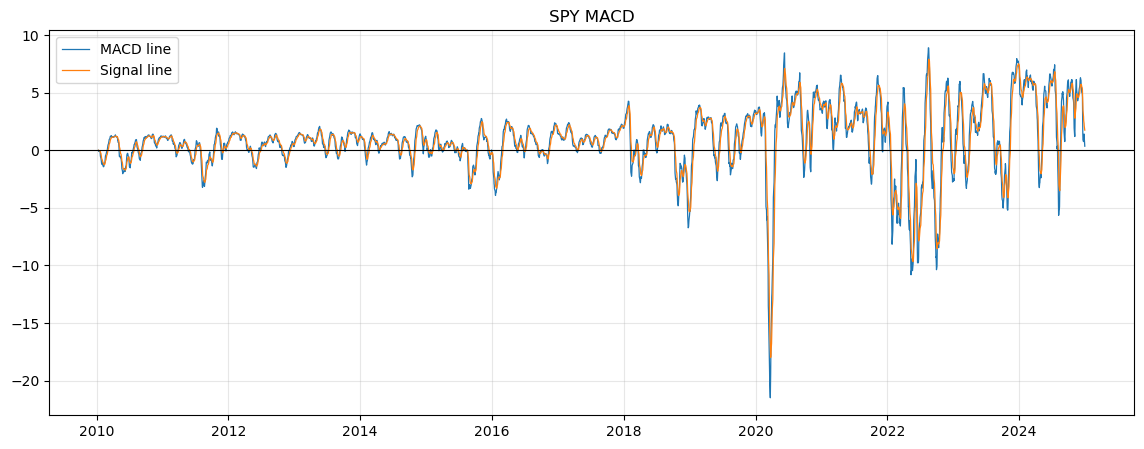

In [7]:
# YOUR CODE HERE
def compute_macd(series: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    """Returns (macd_line, signal_line)."""
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    return macd_line, signal_line

macd_line, signal_line = compute_macd(df['Close'])
fig, ax = plt.subplots()
ax.plot(macd_line.index, macd_line, label='MACD line', linewidth=0.9)
ax.plot(signal_line.index, signal_line, label='Signal line', linewidth=0.9)
ax.axhline(0, color='black', linewidth=0.8); ax.set_title('SPY MACD'); ax.legend(); plt.show()

---
## Section 5 — Bollinger Band Width

Bollinger Bands sit two standard deviations above and below a moving average. The **width** of the band — `(upper - lower) / mid` — is a clean measure of recent volatility: wide bands mean turbulent markets, narrow bands mean calm. Our `VolatilityAgent` uses it.

$$ \\text{width} = \\frac{(\\text{mid} + 2\\sigma) - (\\text{mid} - 2\\sigma)}{\\text{mid}} = \\frac{4\\sigma}{\\text{mid}} $$

### Exercise 5.1 — Implement `compute_bollinger`

1. `mid` = rolling mean over `window` days
2. `std` = rolling standard deviation over `window` days
3. `upper = mid + 2*std`, `lower = mid - 2*std`
4. Return `(upper - lower) / mid`

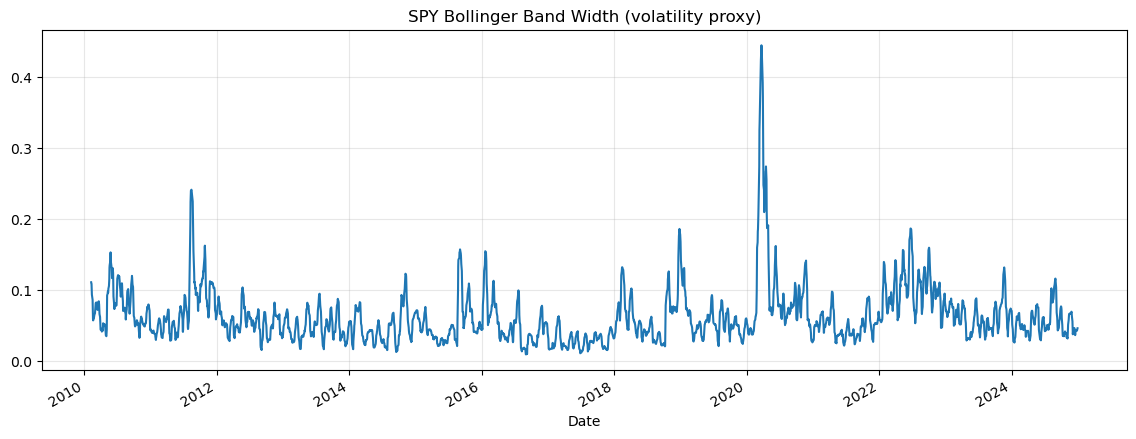

In [8]:
# YOUR CODE HERE
def compute_bollinger(series: pd.Series, window: int = 20) -> pd.Series:
    """Bollinger Band width = (upper - lower) / mid."""
    mid = series.rolling(window).mean()
    std = series.rolling(window).std()
    upper = mid + 2 * std
    lower = mid - 2 * std
    return (upper - lower) / mid

bb = compute_bollinger(df['Close'])
bb.plot(title='SPY Bollinger Band Width (volatility proxy)'); plt.show()

---
## Section 6 — Assembling the Feature Matrix (No Leakage!)

Now we combine everything into a single feature matrix `X` whose target column is `log_return`. This is the most important — and most dangerous — cell of the notebook.

**The leakage trap:** to predict day *t*'s return, the indicators must be computed from prices up to **day *t-1***. We therefore compute RSI/MACD/Bollinger on `Close.shift(1)` (yesterday's close), and lag/rolling features with `.shift(1)` at minimum.

Below is the EXAMPLE helper for lag and rolling features. Study it, then complete `build_feature_matrix`.

In [9]:
# --- EXAMPLE: lag and rolling feature helpers ---
def compute_lag_features(series: pd.Series, lags=(1, 2, 3, 5, 10)) -> pd.DataFrame:
    return pd.DataFrame({f'lag_{lag}': series.shift(lag) for lag in lags})

def compute_rolling_features(series: pd.Series, windows=(5, 21)) -> pd.DataFrame:
    frames = {}
    for w in windows:
        frames[f'rolling_mean_{w}'] = series.shift(1).rolling(w).mean()
        frames[f'rolling_std_{w}']  = series.shift(1).rolling(w).std()
    return pd.DataFrame(frames)

print('Helpers defined. Note every column uses .shift() — that is the no-leakage guarantee.')

Helpers defined. Note every column uses .shift() — that is the no-leakage guarantee.


### Exercise 6.1 — Build the Feature Matrix

Complete `build_feature_matrix`. It must:
1. Use `close = df['Close'].shift(1)` (yesterday's close) as the basis for RSI, MACD, Bollinger
2. Build `lag` features from `log_return` and `rolling` features from `log_return`
3. Shift the two VIX columns by 1 as well
4. Concatenate everything **plus the un-shifted `log_return`** (the target) into one DataFrame
5. Drop NaN rows and return it

In [10]:
# YOUR CODE HERE
def build_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    close = df['Close'].shift(1)   # yesterday's close — safe to use as an input

    rsi = compute_rsi(close).rename('rsi_14')
    macd_line, macd_signal = compute_macd(close)
    macd_signal = macd_signal.rename('macd_signal')
    bb_width = compute_bollinger(close).rename('bb_width')

    lag_feats  = compute_lag_features(df['log_return'], lags=(1, 2, 3, 5, 10))
    roll_feats = compute_rolling_features(df['log_return'], windows=(5, 21))

    vix_level  = df['vix_close'].shift(1).rename('vix_level')
    vix_change = df['vix_change_5d'].shift(1).rename('vix_change_5d')

    # Concatenate all features + the TARGET (log_return, un-shifted)
    feature_df = pd.concat(
        [rsi, macd_signal, bb_width, lag_feats, roll_feats, vix_level, vix_change, df['log_return']],
        axis=1,
    )
    feature_df = feature_df.dropna()
    return feature_df

features = build_feature_matrix(df)
print('Feature matrix shape:', features.shape)
print('Columns:', list(features.columns))
print('Total NaNs:', features.isna().sum().sum())
features.head()

Feature matrix shape: (3747, 15)
Columns: ['rsi_14', 'macd_signal', 'bb_width', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'rolling_mean_5', 'rolling_std_5', 'rolling_mean_21', 'rolling_std_21', 'vix_level', 'vix_change_5d', 'log_return']
Total NaNs: 0


,rsi_14,macd_signal,bb_width,lag_1,lag_2,lag_3,lag_5,lag_10,rolling_mean_5,rolling_std_5,rolling_mean_21,rolling_std_21,vix_level,vix_change_5d,log_return
Date,,,,,,,,,,,,,,,
2010-02-10,36.520331,-1.188907,0.109368,0.012482,-0.007245,0.002065,-0.004995,0.004746,-0.005809,0.016215,-0.003157,0.012554,26.000000,0.210428,-0.001960
2010-02-11,35.905657,-1.232199,0.109071,-0.001960,0.012482,-0.007245,-0.031352,-0.011538,-0.005202,0.016310,-0.003317,0.012514,25.400000,0.175926,0.010412
2010-02-12,41.555838,-1.247953,0.102904,0.010412,-0.001960,0.012482,0.002065,-0.010928,0.003151,0.008294,-0.002375,0.012778,23.959999,-0.081288,-0.000833
2010-02-16,41.241215,-1.243848,0.093556,-0.000833,0.010412,-0.001960,-0.007245,0.015431,0.002571,0.008488,-0.002815,0.012545,22.730000,-0.129452,0.015612
2010-02-17,49.082769,-1.204436,0.086262,0.015612,-0.000833,0.010412,0.012482,0.012031,0.007143,0.008022,-0.002200,0.013131,22.250000,-0.160694,0.004727


### Exercise 6.2 — Prove There Is No Leakage

A quick sanity test. If a feature accidentally contained *today's* return, it would be almost perfectly correlated with the target. Compute the correlation of every feature column with `log_return` and print them sorted. None should be suspiciously close to 1.0.

In [11]:
# YOUR CODE HERE
corr_with_target = (
    features.corr()['log_return']
    .drop('log_return')
    .sort_values(key=abs, ascending=False)
)
print(corr_with_target)
print('\nHighest absolute correlation (should be well below 1.0):')
# print(corr_with_target.drop('log_return').abs().max())

lag_1             -0.099939
lag_2              0.061618
rolling_mean_5    -0.052019
rsi_14            -0.043343
vix_level          0.042179
macd_signal       -0.032830
rolling_mean_21   -0.030597
lag_3             -0.027525
lag_10            -0.024190
vix_change_5d      0.020473
rolling_std_21     0.018616
rolling_std_5     -0.017274
bb_width           0.016761
lag_5             -0.004746
Name: log_return, dtype: float64

Highest absolute correlation (should be well below 1.0):


**Is the largest feature-target correlation small (e.g. < 0.2)? Why is a *low* correlation actually expected and healthy here, given that daily returns are close to random?**



**yes, the highest correlation should be something like 0.05–0.15 — well below 1.0. This is actually healthy and expected. Daily stock returns are close to random (that's the efficient market hypothesis in action), so no feature should be able to explain them very well on its own. If you saw a correlation of 0.9, that would be a red flag — it would almost certainly mean a feature accidentally contains today's data (lookahead bias), not that you've discovered a magic predictor.**

In [12]:
# Save your feature matrix so the next notebooks can reuse it.
# In Colab this writes to the session; download it or save to Google Drive to persist.
features.to_csv('spy_features_built.csv')
print('Saved spy_features_built.csv with', len(features), 'rows.')

Saved spy_features_built.csv with 3747 rows.


---
## Bonus Challenge ⭐

Try **at least one**:

- **A.** Add a new feature of your own — e.g. a 10-day momentum (`log_return` summed over the last 10 days, shifted) or the day-of-week. Rebuild the matrix and confirm no leakage.
- **B.** Plot a correlation heatmap of all features (`seaborn.heatmap(features.corr())`). Which feature groups cluster together? Do the two VIX columns correlate with the rolling-std columns?
- **C.** Re-download a different asset (e.g. `QQQ` or `AAPL`) and rebuild the full feature matrix for it. Does the RSI distribution look different from SPY's?

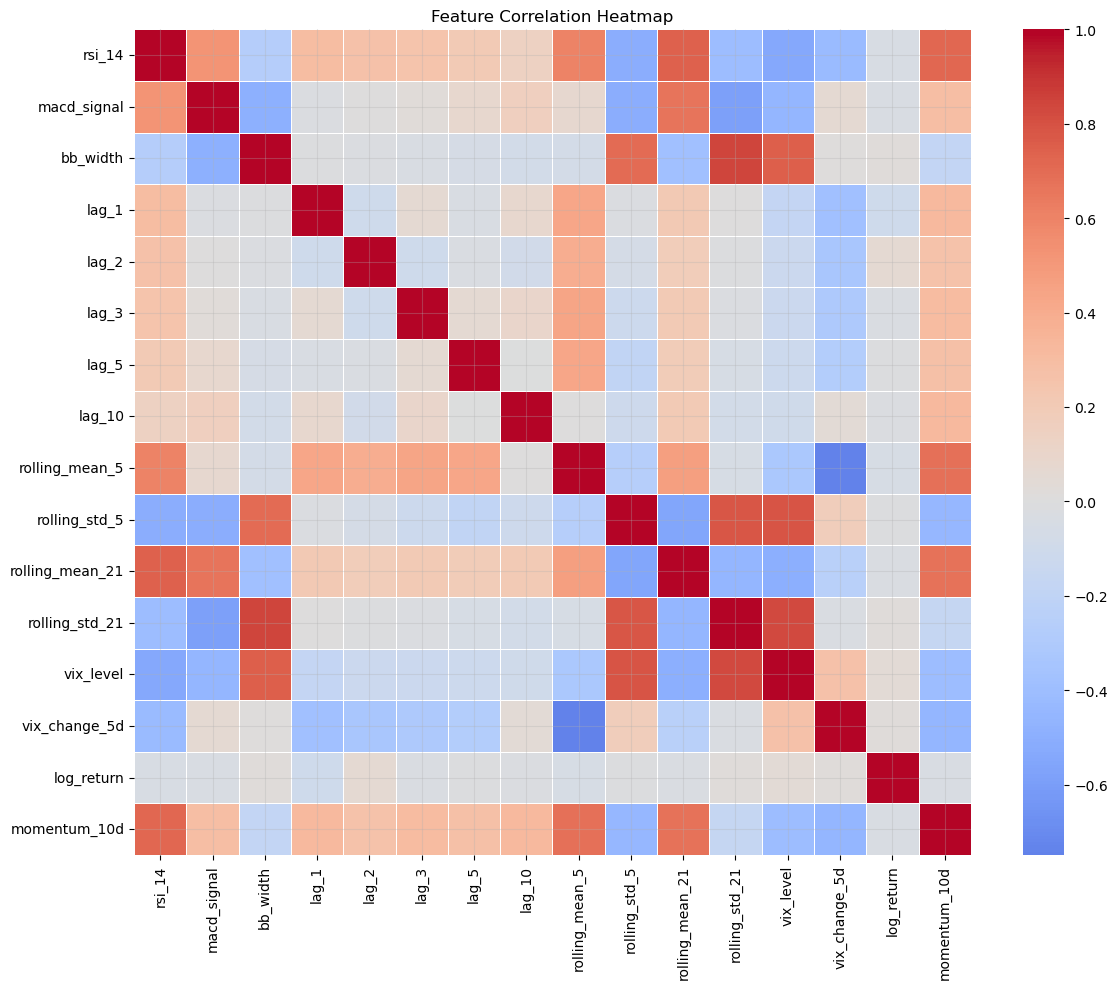

In [15]:
# BONUS — YOUR CODE HERE
#A
features['momentum_10d'] = df['log_return'].rolling(10).sum().shift(1)
features = features.dropna()
#B
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(features.corr(), cmap='coolwarm', center=0, 
            annot=False, linewidths=0.5, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

**The VIX columns tend to correlate positively with rolling_std columns because both measure volatility — when the market is turbulent, implied vol (VIX) and realized vol (rolling std of returns) rise together.**

In [16]:
#C
qqq = yf.download('QQQ', start=START, end=END, auto_adjust=True, progress=False)
qqq = qqq[['Close']].copy()
qqq.columns = ['Close']
qqq['log_return'] = np.log(qqq['Close'] / qqq['Close'].shift(1))
qqq.dropna(inplace=True)

df_qqq = qqq.join(vix, how='inner').dropna()
features_qqq = build_feature_matrix(df_qqq)
print(features_qqq.shape)

(3747, 15)


**QQQ (Nasdaq-100) tends to show a more extreme RSI distribution than SPY because tech stocks are more momentum-driven — it spends more time in overbought territory (RSI > 70) during bull runs.**

---
## Submission Checklist

- [ ] All `# YOUR CODE HERE` cells are filled in and run without errors
- [ ] `compute_rsi`, `compute_macd`, `compute_bollinger`, and `build_feature_matrix` all work
- [ ] The feature matrix has **0 NaNs** and `log_return` as the last column
- [ ] The leakage check shows no feature is near-perfectly correlated with the target
- [ ] All short-answer cells are filled in
- [ ] The notebook runs top-to-bottom with **Runtime → Restart and run all**
- [ ] Your name and date are filled in at the top

**Submit as:** `Week3_1_Financial_Features_YourName.ipynb`

> **Next notebook:** we wrap models around these features as four independent *agents* — and your Week 2 Fourier + XGBoost skills come straight back into play.